![](https://raw.githubusercontent.com/wateraccounting/WaPORMOOC/main/images/banner_notebooks_WaPOR4Global.png)

<i>Module Two</i> – <b>Estimating irrigated areas using GEE</b>
</h3>

<p style="color:white; margin-top:5px;">
<b>Notebook:</b> Download WaPOR using GEE &nbsp; | &nbsp;
<b>Estimated time:</b> 2 hours &nbsp; | &nbsp;
<b>Instructor:</b> Dr. Solomon Seyoum
</p>
</div>

</div>

With this notebook, we will explore how to access  WaPOR data (<font  color='#d39aed'> Level 1 </font> and <font color='#d39aed'> Level 2 </font>) using Google Earth Engine in Python. And use GEE to estimate the irrigated area in Erbil.




<div style="border-left:6px solid #1D70B8; background-color:#0B3C5D; padding:15px; border-radius:6px">

### 🎯 Learning Objectives

When you complete this notebook, you will be able to:

- Access WaPOR data through GEE
- Use the data for calculating irrigated areas  
- Modify the code and download the results of the analyses    

</div>

<div style="background-color:#0B3C5D; padding:15px; border-radius:6px">

### 📝 Prerequisites

✔ [Introduction to WaPOR](https://ocw.un-ihe.org/course/view.php?id=263)  
✔ Geospatial data concepts  
✔ [Python basics for geospatial  data analysis](https://ocw.un-ihe.org/course/view.php?id=272)   
✔ Gmail account   
✔ GEE basics    

</div>

---

###  🔀 Workflow Overview
🗺

| Step | Task | Purpose |
|------|------|---------|
| 1 | Environment Setup | importing required packages
| 2 | Input Data Preparation | Set up the input required to run the analyses|
| 3 | Running the analyses | Download the data |
| 4 | Check| Check if the required data is downloaded based on the specification |
| 5 | Optional - Visualize | Visualize the downloaded data |

---

## 📖 WaPOR data access

This notebook is to explore how to access WaPOR data using GEE. WaPOR level 1 and 2 data can be directly accessed in GEE as they are in Earth Engine Data Catalogue. It is possible to implement analyses with WaPOR data using python coding. This script explores this by using WaPOR AETI data to estimate the extent of irrigated areas in Erbil Governorate.

Level 3 are not part of the Earth Engine Data Catalogue and; therefore, to access them, one first needs to upload the level 3 data to their google cloud storage. This Notebook **(add link)** explains the steps on how to do this.



## ⚙️ Environment Setup
<p style="margin-top:1px;">
  Some Python packages are required that may not be included in a basic Python installation. It is also good practice to use an organized folder structure, with your code in one folder and your data in another. The data folder can contain different formats of input and output files. <br><br>
  In the next cells, we will create the necessary folders, upload the download script, and install the required Python packages. <br><br>
  </p>


### Install require packages

In [1]:
# =============================================================================
# Install required package
# =============================================================================

%%capture
!pip install geemap google-cloud-storage earthengine-api rasterio numpy requests

### Import require packages

In [2]:
# =============================================================================
# import packages
# =============================================================================

import ee
import geemap
import re
from google.cloud import storage
import pandas as pd  # data manipulation and analysis
from pandas.tseries.api import guess_datetime_format
import numpy as npm
import json # for handling JSON data (serialization and deserialization)
import time  #  timing operations and delays

import matplotlib.pyplot as plt  # data visualization
import folium  #  interactive maps
from folium import Figure
import branca.colormap as cm  #  color mapping in folium

### Authenticate earth engine

You need to have your Google Cloud project ID and your username to authenticate Earth Engine.

If you do not have an earth engine account, follow the steps explained in [this document](https://github.com/wateraccounting/WaPOR4Global/blob/main/2b_Correlation_Analyses/Creating_Project_GEE_Redacted.pdf) and replace the `***` in the following code with your project_id and user name.

When running this code, it will ask to allow access, which you have to accept to be able to continue with running this Notebook.

In [3]:
# =============================================================================
# Set up project and user ID
# =============================================================================

project_id = 'my-ee-project-497714'# ee-********* 'your GC project ID
user = 'Laura' # ********
ee.Authenticate()  #
ee.Initialize(project=project_id)

### Define some parameters to be used later

Upload the following files to your google asset folder.

| File |  Description |
|------|------------|
| `Erbil.zip` | Contains shapefile of Erbil Governorate |
| `ESA_LC_2021_Erbil_20m.tif` | ESA land cover map Erbil|

![](https://raw.githubusercontent.com/wateraccounting/WaPOR4Global/main/images/GEE_asset_upload.png)

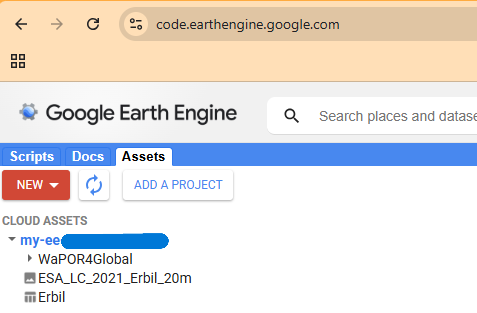

 ✅ **Check your uploads**: In the [Earth Engine Code Editor](https://code.earthengine.google.com), open the **Tasks** tab (top right). Each asset should show a green checkmark ✓ and say **Completed**. If any shows **Failed**, delete the asset and re-upload before continuing.

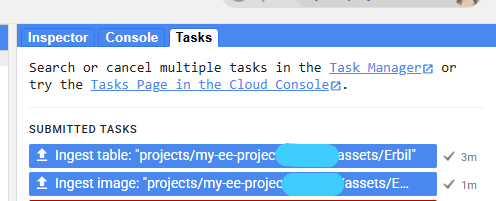


Then run this cell to sets up the initial settings for the code. It defines the asset folder and the link to the shapefile and land cover map. In the first section of the example we first focus on the variable `L2-AETI_D` for the summer (irrigation) season of the year 2024 in the Erbil governorate of Iraq, which requires defining the start and end date of the season.

In [4]:
# =============================================================================
# Define parameters and read area of interest and LC map
# =============================================================================

asset_folder = f"users/{user}/WaPOR4Global" ##*your GEE Legacy Assets user name*##
rio_shape_id = f'projects/{project_id}/assets/Erbil'
rio_lc_id = f'projects/{project_id}/assets/ESA_LC_2021_Erbil_20m'

AOI_name = "Erbil"
area_of_interest = ee.FeatureCollection(rio_shape_id)
ESA_LCC_image = ee.Image(rio_lc_id)
vars_to_download = ['L2-AETI-D']

# Define date range
start_date = "2024-06-01"
end_date = "2024-10-31"

### Function to get the image collections for the required variables and the date specified

Note on WaPOR data access: the data is not yet searchable in Earth Engine data catalogue through its search function, but it can be accessed using the datasets "collection identifiers". These identifiers are:

- projects/UNFAO/wapor/v3/L1-AETI-D
- projects/UNFAO/wapor/v3/L1-E-D
- projects/UNFAO/wapor/v3/L1-I-D
- projects/UNFAO/wapor/v3/L1-T-D
- projects/UNFAO/wapor/v3/L1-NPP-D
- projects/UNFAO/wapor/v3/L1-RET-D
- projects/UNFAO/wapor/v3/L1-RET-E
- projects/UNFAO/wapor/v3/L2-AETI-D
- projects/UNFAO/wapor/v3/L2-E-D
- projects/UNFAO/wapor/v3/L2-I-D
- projects/UNFAO/wapor/v3/L2-T-D
- projects/UNFAO/wapor/v3/L2-NPP-D

*be aware that precipitation and rootzone moisture data are not available even for Level 1 and level 2 data. All data is available at its smallest timestep, i.e. dekadal (except for Reference ET which is also available at daily timestep) and all require to be corrected for their scaling factor and conversion to mm/dekade from the average value of mm/day.*

The following function reads the `vars_to_download` as defined above and correct for scaling factor and multiply by the number of days to account for the unit of the dekadal images being mm/day.

In [5]:
# =============================================================================
# Get image collection for specified variables and dates
# =============================================================================

var_paths_dict = {v: f"projects/UNFAO/wapor/v3/{v}" for v in vars_to_download}
def get_image_wapor(v):

    def process_image(img):
        # Get start and end dates for the image
        start_img_date = ee.Date(img.get('system:time_start'))
        end_img_date = ee.Date(img.get('system:time_end'))
        # Calculate nDays for this specific image's period
        nDays = end_img_date.difference(start_img_date, 'day').add(1)
        # Perform the multiplication: AETI (raw) * 0.1 (scaling to mm) * nDays (days in period)
        return (img.multiply(0.1).multiply(nDays)
                .copyProperties(img, img.propertyNames())
                .set('date', img.date().format('YYYY-MM-DD')))

    return (
      ee.ImageCollection(v)
      .filterDate(start_date, end_date)
      .map(process_image)
    )

var_collections_dict = {k: get_image_wapor(v) for k, v in var_paths_dict.items()}

---
### Inspect and visualise the image collection

Lets inspect the image collection, how many elements does the collection contain?

In [6]:
# =============================================================================
# Inspect image collection
# =============================================================================

var_collections_dict['L2-AETI-D']

Get information about the image collection such as band names projection and scale

In [7]:
# =============================================================================
# Check details of image collection
# =============================================================================

def get_image_coll_info(img_cols):
  first_image = ee.Image(img_cols.first())
  band_names = first_image.bandNames()
  projection = first_image.projection()
  scale = first_image.projection().nominalScale()
  return  projection, scale, band_names

for v in var_collections_dict.keys():
  projection, scale, band_names = get_image_coll_info(var_collections_dict[v])
  print(f"Band_names: {band_names.getInfo()} projection: {projection.getInfo()}, scale: {scale.getInfo()}")

Band_names: ['L2-AETI-D'] projection: {'type': 'Projection', 'crs': 'EPSG:4326', 'transform': [0.0009765625, 0, -180, 0, -0.0009765625, 60]}, scale: 108.71044022780622


Visualise the first image of the image collection (first dekade of June 2024).This will display the image collection which contains the entire area covered by L2 data.

In [8]:
# =============================================================================
# Visualise first image of image collection
# =============================================================================

#  min and max
min_val, max_val = 0, 100

# Set visualization parameters
abst_vis_params = {
    "min": min_val,
    "max":max_val,
    "palette": [
       '#d7191c',
       '#fdae61',
       '#ffffbf',
       '#a6d96a',
       '#1a9641'
  ]
}
var_to_map = [x for x in vars_to_download if "AETI" in x]
Map = geemap.Map(height="600px", width="800px")
if len(var_to_map) >0:
  img = var_collections_dict[var_to_map[0]].first()
  Map.centerObject(area_of_interest, 8)
  Map.addLayer(img, abst_vis_params, "WaPOR AETI")
  Map.add_colorbar(abst_vis_params, label="Summed AETI Value", orientation="horizontal", layer_name="Summed WaPOR AETI")
  Map.addLayerControl()

Map

Map(center=[36.34423670990206, 44.23309765651537], controls=(WidgetControl(options=['position', 'transparent_b…

### Clip the image collection using the area of interest

Lets clip the image collection using the area of interest and visualise the results.

In [9]:
# =============================================================================
# Function to clip each image
# =============================================================================

var_collections_clipped_dict = {k: ee.ImageCollection(v).filterBounds(area_of_interest).map(lambda img: img.clip(area_of_interest)) for k, v in var_collections_dict.items()}
var_collections_clipped_dict['L2-AETI-D']

In [10]:
# =============================================================================
# Visualise first image of image collection
# =============================================================================

#  min and max
min_val, max_val = 0, 100

# Set visualization parameters
abst_vis_params = {
    "min": min_val,
    "max":max_val,
    "palette": [
       '#d7191c',
       '#fdae61',
       '#ffffbf',
       '#a6d96a',
       '#1a9641'
  ]
}
var_to_map = [x for x in vars_to_download if "AETI" in x]
Map = geemap.Map(height="600px", width="800px")
if len(var_to_map) >0:
  img = var_collections_clipped_dict[var_to_map[0]].first()
  Map.centerObject(area_of_interest, 8)
  Map.addLayer(img, abst_vis_params, "WaPOR AETI")
  Map.add_colorbar(abst_vis_params, label="Summed AETI Value", orientation="horizontal", layer_name="Summed WaPOR AETI")
  Map.addLayerControl()

Map

Map(center=[36.344236709902056, 44.23309765651536], controls=(WidgetControl(options=['position', 'transparent_…

---

### Estimating irrigated areas
To assess where irrigation is taking place during the dry season (June-October), we assume that irrigation is taking place in cropland where  the seasonal AETI exceeds a certain value. The following steps are followed:

- calculating the seasonal AETI by summing up the values of the dekades within the period.
- create a mask where seasonal AETI exceeds a defined threshold `>350 mm`
- create a mask of cropland area `lcc = 40` based on the ESA land cover map
- create irrigated area mask where seasonal AETI exceeds a defined threshold `>350 mm` and mask for cropland mask
- calculate irrigated area


In [11]:
# =============================================================================
# CALCULATE SEASONAL AETI
# =============================================================================

aeti_sum = (
    var_collections_clipped_dict["L2-AETI-D"]
    .filterDate(start_date, end_date)
    .map(lambda img: img.unmask(0).toFloat())
    # .select("precipitation")
    .sum()
).clip(area_of_interest)
aeti_sum
aeti_sum.getInfo()

{'type': 'Image',
 'bands': [{'id': 'L2-AETI-D',
   'data_type': {'type': 'PixelType', 'precision': 'double'},
   'crs': 'EPSG:4326',
   'crs_transform': [1, 0, 0, 0, 1, 0]}]}

In [12]:
# =============================================================================
# VISUALISE SEASONAL AETI
# =============================================================================

#  min and max for visualization
min_val, max_val = 0, 500

# Set visualization parameters
abst_vis_params = {
    "min": min_val,
    "max":max_val,
    "palette": [
       '#d7191c',
       '#fdae61',
       '#ffffbf',
       '#a6d96a',
       '#1a9641'
  ]}

# Visualize the summed AETI map
var_to_map = [x for x in vars_to_download if "AETI" in x]
Map_sum = geemap.Map(height="600px", width="800px")

if len(var_to_map) >0:
  Map_sum.centerObject(area_of_interest, 8)
  Map_sum.addLayer(aeti_sum, abst_vis_params, "Summed WaPOR AETI")
# Add the colorbar (legend)
  Map_sum.add_colorbar(abst_vis_params, label="Summed AETI Value", orientation="horizontal", layer_name="Summed WaPOR AETI")
  Map_sum.addLayerControl()
Map_sum

Map(center=[36.34423670990206, 44.23309765651537], controls=(WidgetControl(options=['position', 'transparent_b…

In [13]:
# =============================================================================
# CALCULATE STATS OF SEASONAL AETI
# =============================================================================

stats = aeti_sum.reduceRegion(
    reducer=ee.Reducer.minMax().combine(ee.Reducer.mean(), None, True).combine(ee.Reducer.stdDev(), None, True),
    geometry=area_of_interest,
    scale=5000,
    maxPixels=1e13
)

print(stats.getInfo())

{'L2-AETI-D_max': 705.5, 'L2-AETI-D_mean': 186.77489483452308, 'L2-AETI-D_min': 11.100000023841858, 'L2-AETI-D_stdDev': 122.87529285159526}


In [14]:
# =============================================================================
# CALCULATE SEASONAL AETI
# =============================================================================

erbil_geom = area_of_interest.geometry()
aeti_col = ee.ImageCollection('projects/UNFAO/wapor/v3/L2-AETI-D')

aeti_sum = (
    aeti_col
    .filterDate(start_date, end_date)
    .map(lambda img: img.unmask(0).toFloat())
    .sum()
).clip(erbil_geom)

Apply a threshold of 350 mm/season to distinguish between irrigated and non-irrigated. Visualise where AETI is greater than `gte` the threshold.

In [15]:
# =============================================================================
# MASK AREA FOR WHERE SEASONAL AETI => 350 mm
# =============================================================================

irrigation_threshold_mm = 350
irr = aeti_sum.gte(irrigation_threshold_mm).selfMask().rename('irrigation')

M = geemap.Map(height='600px', width='800px'); M.centerObject(area_of_interest, 8)
M.addLayer(irr, {'palette':['#1f78b4']}, 'Irrigation')
M.add_colorbar(label='Irrigated plots', orientation='horizontal', layer_name='irr')
M.addLayerControl(); M

Map(center=[36.344236709902056, 44.23309765651536], controls=(WidgetControl(options=['position', 'transparent_…

Calculate area where seasonal AETI is larger than the threshold

In [16]:
# =============================================================================
# CALCULATE AREA WHERE SEASONAL AETI > THRESHOLD
# =============================================================================

# Calculate the area from the 'irr' image
irr_area_m2 = irr.multiply(ee.Image.pixelArea()).reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=area_of_interest,
    scale=100, # Use the scale of the AETI data
    maxPixels=1e9
).get('irrigation').getInfo()

irr_area_km2 = irr_area_m2 / 1e6
print(f'Area where AETI >= {irrigation_threshold_mm:.0f} mm: {irr_area_km2:.2f} km²')

Area where AETI >= 350 mm: 1931.29 km²


Many of the areas with AETI>=350mm are not located in cropland. Therefore the area is masked by a Land cover land use map (CROPLAND class = 40). First the mask is created (using locally uploaded shapefile of Erbil and ESA_LC map of 2021) and cropland area calculated.


In [17]:
# =============================================================================
# Create cropland mask + calculate area using Earth Engine
# =============================================================================

# CROP_CODE is already defined
CROP_CODE = 40 # Assuming 40 is the crop code

# Clip the ESA_LCC_image to the area_of_interest
clipped_lc_image = ESA_LCC_image.clip(area_of_interest)

# Create a cropland mask (where value == CROP_CODE)
# The result will be an image with 1 where it's cropland, 0 otherwise
cropland_mask_ee = clipped_lc_image.eq(CROP_CODE).selfMask() # selfMask makes non-cropland pixels transparent (null)

# Calculate the area of each pixel in the cropland mask
pixel_area_image = cropland_mask_ee.multiply(ee.Image.pixelArea())

# Sum the pixel areas within the area of interest to get the total cropland area
cropland_area_m2 = pixel_area_image.reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=area_of_interest,
    scale=ESA_LCC_image.projection().nominalScale(), # Use the native scale of the LC image
    maxPixels=1e9 # Increase maxPixels for larger areas if needed
).get(ESA_LCC_image.bandNames().get(0)).getInfo() # Get the name of the first band dynamically

cropland_area_km2 = cropland_area_m2 / 1e6

print(f'Erbil cropland area (ESA LC 2021, class {CROP_CODE}): {cropland_area_km2:.2f} km²')

Erbil cropland area (ESA LC 2021, class 40): 4743.80 km²


The final step is to calculate the irrigated area by masking the area where the seasonal AETI > 350mm with the cropland mask and then calculating the area.

In [18]:
# =============================================================================
# CALCULATE IRRIGATED AREA
# =============================================================================

import geemap

erbil_geom = area_of_interest.geometry()
# Resample cropland mask to 100m using mode (majority class within 100m pixel)
cropland_mask_100m = clipped_lc_image \
    .reduceResolution(
        reducer=ee.Reducer.mode(),
        maxPixels=256
    ) \
    .reproject(crs=aeti_sum.projection(), scale=100) \
    .eq(CROP_CODE) \
    .selfMask() \
    .rename('Cropland_Mask')

# Mask the 'irr' image with the cropland mask
irr_cropland = irr.updateMask(cropland_mask_100m).rename('irrigation_cropland')

# Calculate irrigated area from `irr_cropland` image
irrigated_area_m2 = irr_cropland.multiply(ee.Image.pixelArea()).reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=erbil_geom,   # ← area_of_interest
    scale=100,
    maxPixels=1e9
).get('irrigation_cropland').getInfo()

irrigated_area_km2 = irrigated_area_m2 / 1e6
print(f'Irrigated area in cropland (AETI >= 350mm): {irrigated_area_km2:.2f} km²')

M_masked = geemap.Map(height='600px', width='800px'); M_masked.centerObject(area_of_interest, 8)
M_masked.addLayer(irr_cropland, {'palette':['#1f78b4']}, 'Irrigation on Cropland')
M_masked.add_colorbar(label='Irrigated plots on Cropland', orientation='horizontal', layer_name='irrigation_cropland')
M_masked.addLayerControl(); M_masked

Irrigated area in cropland (AETI >= 350mm): 167.19 km²


Map(center=[36.34423670990206, 44.23309765651537], controls=(WidgetControl(options=['position', 'transparent_b…

---
## Calculating irrigated area per season

Now that you understand the different steps, the following cell calculates the seasonal values for multiple years using a loop. First the season start and end are defined as `yyyy-06-01` and `yyyy-10-31` for a specified range in `season_periods`.  

In [19]:
# =============================================================================
# CALCULATE IRRIGATED AREA FOR 2018-2025
# =============================================================================

import os, pandas as pd

season_periods = {f'season{y}': {'SOS': f'{y}-06-01', 'EOS': f'{y}-10-31'} for y in range(2018, 2025)}

irrigation_threshold_mm = 350
aeti_col = ee.ImageCollection('projects/UNFAO/wapor/v3/L2-AETI-D')
erbil_geom = area_of_interest.geometry()
EXPORT_DIR = 'Erbil/aeti_exports'; os.makedirs(EXPORT_DIR, exist_ok=True)

def aeti_sum_mm(s, e):
    return (
        aeti_col
        .filterDate(s, e)
        .map(lambda img: img.unmask(0).toFloat())  # ← match aeti_sum processing
        .sum()
        .clip(erbil_geom)
        .rename('AETI_mm')
    )

rows = []
for name, d in season_periods.items():
    y, sos, eos = int(name[6:]), d['SOS'], d['EOS']
    s_tif = f'{EXPORT_DIR}/seasonal_{y}.tif'

    # Export seasonal AETI
    geemap.ee_export_image(aeti_sum_mm(sos, eos), filename=s_tif, scale=100, region=erbil_geom, file_per_band=False)

    # Calculate irrigated area from AETI mask using threshold
    aeti_irrigated_image = aeti_sum_mm(sos, eos).gte(irrigation_threshold_mm).updateMask(cropland_mask_100m).rename('AETI_Irrigated_Mask')
    irrigated_area_m2_ee = aeti_irrigated_image.multiply(ee.Image.pixelArea()).reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=erbil_geom,
        scale=100,
        maxPixels=1e9
    ).get('AETI_Irrigated_Mask').getInfo()
    irrigated_area_km2 = irrigated_area_m2_ee / 1e6
    perc_irr_area = irrigated_area_km2 / cropland_area_km2 * 100

    # Calculate seasonal AETI within the irrigated area
    seasonal_aeti_ee = aeti_sum_mm(sos, eos).updateMask(aeti_irrigated_image).reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=erbil_geom,
        scale=100,
        maxPixels=1e9
    ).get('AETI_mm').getInfo()

    rows.append({'season': name, 'year': y, 'SOS': sos, 'EOS': eos,
                 'seasonal_AETI_mm': seasonal_aeti_ee,
                 'irrigated_area_km2': irrigated_area_km2,
                 'percentage irrigated area': perc_irr_area})
    print(f'{name}: seasonal={rows[-1]["seasonal_AETI_mm"]:.1f} mm  |  irrigated={irrigated_area_km2:.2f} km²')

results_df = pd.DataFrame(rows)
results_df['seasonal_AETI_mm'] = results_df['seasonal_AETI_mm'].round(2)
results_df['irrigated_area_km2'] = results_df['irrigated_area_km2'].round(2)
results_df['percentage irrigated area'] = results_df['percentage irrigated area'].round(2)
results_df.to_csv('Erbil/erbil_seasonal_aeti.csv', index=False)
results_df

Generating URL ...
Please wait ...
Data downloaded to /content/Erbil/aeti_exports/seasonal_2018.tif
season2018: seasonal=479.6 mm  |  irrigated=136.34 km²
Generating URL ...
Please wait ...
Data downloaded to /content/Erbil/aeti_exports/seasonal_2019.tif
season2019: seasonal=479.9 mm  |  irrigated=201.65 km²
Generating URL ...
Please wait ...
Data downloaded to /content/Erbil/aeti_exports/seasonal_2020.tif
season2020: seasonal=486.7 mm  |  irrigated=170.07 km²
Generating URL ...
Please wait ...
Data downloaded to /content/Erbil/aeti_exports/seasonal_2021.tif
season2021: seasonal=492.3 mm  |  irrigated=134.36 km²
Generating URL ...
Please wait ...
Data downloaded to /content/Erbil/aeti_exports/seasonal_2022.tif
season2022: seasonal=494.8 mm  |  irrigated=245.39 km²
Generating URL ...
Please wait ...
Data downloaded to /content/Erbil/aeti_exports/seasonal_2023.tif
season2023: seasonal=493.7 mm  |  irrigated=166.60 km²
Generating URL ...
Please wait ...
Data downloaded to /content/Erbil/a

,season,year,SOS,EOS,seasonal_AETI_mm,irrigated_area_km2,percentage irrigated area
0,season2018,2018,2018-06-01,2018-10-31,479.65,136.34,2.87
1,season2019,2019,2019-06-01,2019-10-31,479.93,201.65,4.25
2,season2020,2020,2020-06-01,2020-10-31,486.68,170.07,3.59
3,season2021,2021,2021-06-01,2021-10-31,492.26,134.36,2.83
4,season2022,2022,2022-06-01,2022-10-31,494.81,245.39,5.17
5,season2023,2023,2023-06-01,2023-10-31,493.68,166.60,3.51
6,season2024,2024,2024-06-01,2024-10-31,497.93,167.19,3.52


---
## Visualise results


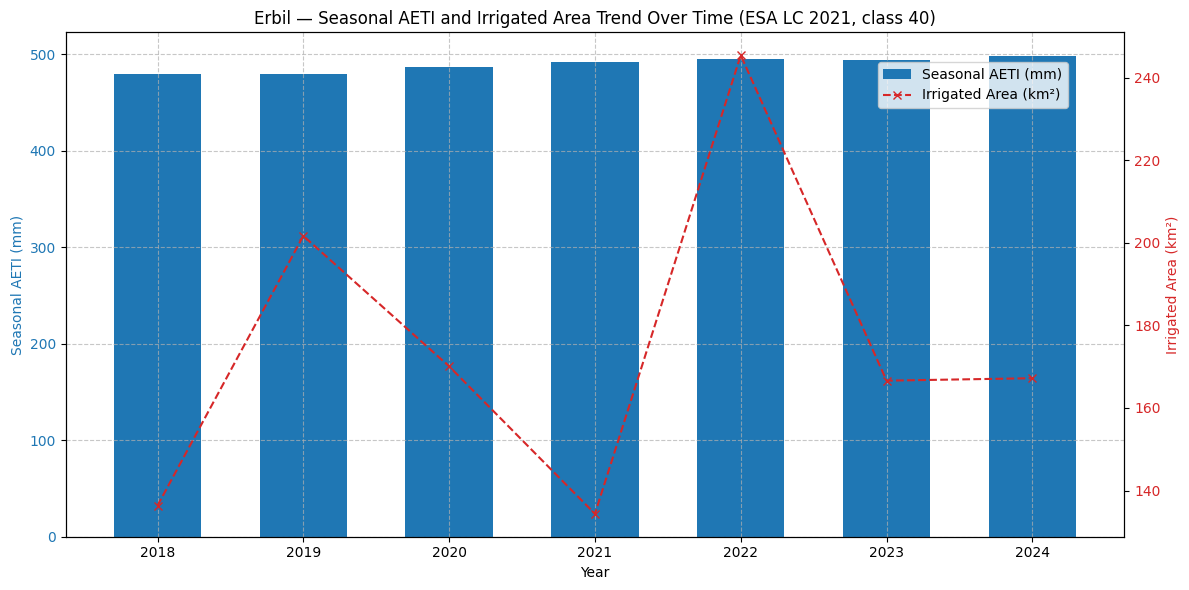

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data from results_df
years = results_df['year'].to_numpy()
seasonal_aeti = results_df['seasonal_AETI_mm'].to_numpy()
irrigated_area = results_df['irrigated_area_km2'].to_numpy()

# Create the figure and the primary axes for seasonal AETI
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Seasonal AETI on the primary y-axis as a bar chart
w = 0.6
ax1.bar(years, seasonal_aeti, width=w, label='Seasonal AETI (mm)', color='tab:blue')
ax1.set_xlabel('Year')
ax1.set_ylabel('Seasonal AETI (mm)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_xticks(years) # Ensure all years are shown as ticks
ax1.grid(True, linestyle='--', alpha=0.7)

# Create a secondary y-axis for Irrigated Area
ax2 = ax1.twinx()
ax2.plot(years, irrigated_area, color='tab:red', marker='x', linestyle='--', label='Irrigated Area (km²)')
ax2.set_ylabel('Irrigated Area (km²)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Add title and combined legend
plt.title(f'Erbil — Seasonal AETI and Irrigated Area Trend Over Time (ESA LC 2021, class {CROP_CODE})')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))

plt.tight_layout()
plt.savefig('Erbil/erbil_seasonalaeti_irrigatedarea.png', dpi=150, bbox_inches='tight')
plt.show()

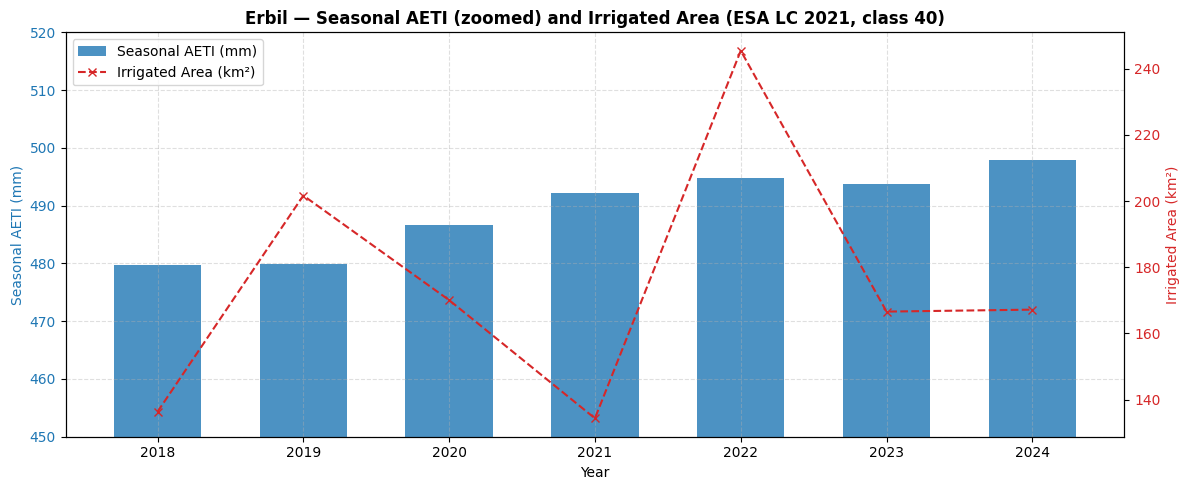

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data from results_df
years = results_df['year'].to_numpy()
seasonal_aeti = results_df['seasonal_AETI_mm'].to_numpy()
irrigated_area = results_df['irrigated_area_km2'].to_numpy()
aeti_anomaly = seasonal_aeti - seasonal_aeti.mean()

# Create the figure and the primary axes for seasonal AETI
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

# Plot Seasonal AETI on the primary y-axis as a bar chart
ax1.bar(years, seasonal_aeti, width=0.6, label='Seasonal AETI (mm)', color='tab:blue', alpha=0.8)
ax1.set_ylabel('Seasonal AETI (mm)', color='tab:blue')
ax1.set_ylim(450, 520) #zoom
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_xticks(years)
ax1.set_xlabel('Year')
ax1.grid(True, linestyle='--', alpha=0.4)

# Add title and combined legend
ax1.set_title(f'Erbil — Seasonal AETI (zoomed) and Irrigated Area (ESA LC 2021, class {CROP_CODE})', fontweight='bold')

# Create a secondary y-axis for Irrigated Area
ax2.plot(years, irrigated_area, color='tab:red', marker='x', linestyle='--', label='Irrigated Area (km²)')
ax2.set_ylabel('Irrigated Area (km²)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('Erbil/erbil_aeti_zoomed.png', dpi=150, bbox_inches='tight')
plt.show()

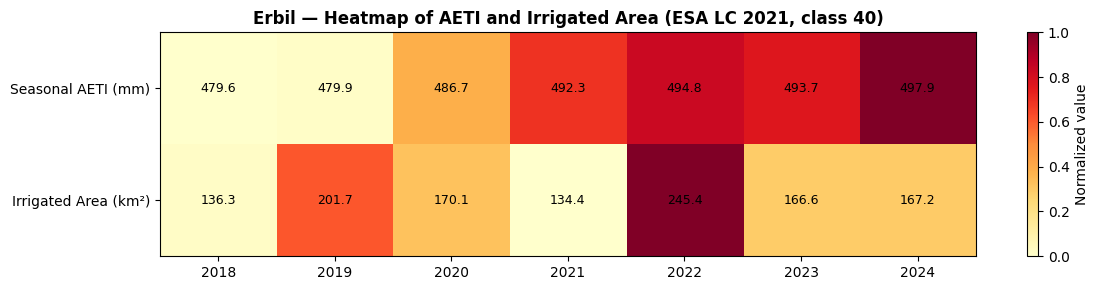

In [22]:
# =============================================================================
# PLOT — Heatmap: intensity by year
# =============================================================================
import matplotlib.colors as mcolors

data_matrix = np.array([seasonal_aeti, irrigated_area])
row_labels = ['Seasonal AETI (mm)', 'Irrigated Area (km²)']

# Normalize each row independently for fair color comparison
data_norm = (data_matrix - data_matrix.min(axis=1, keepdims=True)) / \
            (data_matrix.max(axis=1, keepdims=True) - data_matrix.min(axis=1, keepdims=True))

fig, ax = plt.subplots(figsize=(12, 3))
im = ax.imshow(data_norm, cmap='YlOrRd', aspect='auto')

ax.set_xticks(np.arange(len(years)))
ax.set_xticklabels(years)
ax.set_yticks(np.arange(len(row_labels)))
ax.set_yticklabels(row_labels)

# Annotate with actual values
for i in range(data_matrix.shape[0]):
    for j in range(data_matrix.shape[1]):
        ax.text(j, i, f'{data_matrix[i, j]:.1f}', ha='center', va='center', fontsize=9)

plt.colorbar(im, ax=ax, label='Normalized value')
ax.set_title(f'Erbil — Heatmap of AETI and Irrigated Area (ESA LC 2021, class {CROP_CODE})', fontweight='bold')

plt.tight_layout()
plt.savefig('Erbil/erbil_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

 ## 🌧️☔ Precipitation (PCP) data from WaPOR is not available in GEE but CHIRPS is available.



### Download CHIRPS daily precipitation data

[CHIRPS](https://www.chc.ucsb.edu/data/chirps) (Climate Hazards Group InfraRed Precipitation with Station data) is a global daily rainfall dataset at ~5 km spatial resolution, available from 1981 to present. It combines satellite imagery with ground station data, making it suitable for areas with sparse rain gauge coverage such as Erbil.

Since WaPOR PCP data is not available in GEE, CHIRPS is used as a substitute and will later be resampled to match WaPOR's spatial and temporal resolution.

The dataset is filtered to the **rainy season (November 2023 – May 2024)** to match the AETI period used in the WDI calculation. Each daily image is processed to:
- Convert pixel values to integer to reduce memory usage (`.toInt()`)
- Preserve all original metadata (`.copyProperties()`)
- Add a readable date string in `YYYY-MM-DD` format for easier inspection


In [23]:
# CHIRPS daily data — rainy season (Nov–May)

wdi_start = "2023-11-01"
wdi_end   = "2024-05-31"

CHIRPS_E = (
    ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY")
    .filterDate(wdi_start, wdi_end)
    .map(lambda img: img.toInt()
         .copyProperties(img, img.propertyNames())
         .set('date', img.date().format('YYYY-MM-DD')))
)

### Aggregate CHIRPS daily data to dekadal resolution

This cell does two things:

**1. Defines `aggregate_collection()`** — a function that collapses all daily images within each date range into a single image using a chosen reducer (`sum` for precipitation).

**2. Generates the dekadal date ranges in Python** and applies the function to `CHIRPS_E`, producing one image per dekad with total rainfall (mm) for that period.

In [24]:
import datetime

# Function to aggregate daily images to the temporal resolution of WaPOR AETI

def aggregate_collection(date_dicts, collection, agg_method='sum'):
    """
    Aggregate an ImageCollection over multiple date ranges.

    Args:
        date_dicts (ee.List or list of dict): each dict must have 'startDate', 'endDate', optionally 'nDays'
        collection (ee.ImageCollection): input collection
        agg_method (str): 'sum', 'mean', 'median', 'max', 'min'

    Returns:
        ee.ImageCollection
    """

    date_dicts = ee.List(date_dicts)

    def aggregate_one(d):
        d = ee.Dictionary(d)

        start = ee.Date(d.get('startDate'))
        end   = ee.Date(d.get('endDate')).advance(1, 'day')

        filtered = collection.filterDate(start, end)

        # Choose reducer
        aggregated = ee.Image(
            ee.Algorithms.If(agg_method == 'sum', filtered.sum(),
            ee.Algorithms.If(agg_method == 'mean', filtered.mean(),
            ee.Algorithms.If(agg_method == 'median', filtered.median(),
            ee.Algorithms.If(agg_method == 'max', filtered.max(),
            ee.Algorithms.If(agg_method == 'min', filtered.min())))))
        )

        # Rename the band to 'precipitation' for consistency, as CHIRPS has this band
        # and sum() defaults to 'sum' band name.
        aggregated = aggregated.rename('precipitation')

        return (aggregated
                .set('system:time_start', start.millis())
                .set('start_date', d.get('startDate'))
                .set('end_date', d.get('endDate'))
                .set('n_days', d.get('nDays')))

    return ee.ImageCollection(date_dicts.map(aggregate_one))

# Define dateRanges for dekadal aggregation
# This part generates a list of dictionaries client-side (Python) and then converts to ee.List

# start_date and end_date are defined globally in the notebook (e.g., '2024-06-01', '2024-10-31')
start_dt = datetime.datetime.strptime(wdi_start, '%Y-%m-%d').date()
end_dt   = datetime.datetime.strptime(wdi_end,   '%Y-%m-%d').date()

dekad_ranges_list = []
current_dt = start_dt

while current_dt <= end_dt:
    year = current_dt.year
    month = current_dt.month
    day = current_dt.day

    dekad_start_dt = current_dt

    if day <= 10:
        dekad_end_dt = datetime.date(year, month, 10)
    elif day <= 20:
        dekad_end_dt = datetime.date(year, month, 20)
    else:
        # Last dekad of the month
        # Find the last day of the current month
        next_month = current_dt.replace(day=28) + datetime.timedelta(days=4)
        dekad_end_dt = next_month - datetime.timedelta(days=next_month.day)

    # Ensure dekad_end_dt does not exceed the overall end_dt
    if dekad_end_dt > end_dt:
        dekad_end_dt = end_dt

    # Ensure dekad_start_dt is not after dekad_end_dt (can happen if current_dt is already past the last dekad_end_dt for the overall end_dt)
    if dekad_start_dt > dekad_end_dt:
      break # Stop if start has passed end

    nDays = (dekad_end_dt - dekad_start_dt).days + 1

    dekad_ranges_list.append({
        'startDate': dekad_start_dt.strftime('%Y-%m-%d'),
        'endDate': dekad_end_dt.strftime('%Y-%m-%d'),
        'nDays': nDays
    })

    # Move to the start of the next dekad
    current_dt = dekad_end_dt + datetime.timedelta(days=1)

dateRanges = ee.List(dekad_ranges_list)

agg_pcp = aggregate_collection(dateRanges, CHIRPS_E, agg_method='sum')


# Optional: print info
print('Aggregated dekadal ImageCollection:')
print(agg_pcp.getInfo())

Aggregated dekadal ImageCollection:
{'type': 'ImageCollection', 'bands': [], 'features': [{'type': 'Image', 'bands': [{'id': 'precipitation', 'data_type': {'type': 'PixelType', 'precision': 'int', 'min': -9.223372036854776e+18, 'max': 9.223372036854776e+18}, 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}], 'properties': {'system:time_start': 1698796800000, 'end_date': '2023-11-10', 'n_days': 10, 'start_date': '2023-11-01', 'system:index': '0'}}, {'type': 'Image', 'bands': [{'id': 'precipitation', 'data_type': {'type': 'PixelType', 'precision': 'int', 'min': -9.223372036854776e+18, 'max': 9.223372036854776e+18}, 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}], 'properties': {'system:time_start': 1699660800000, 'end_date': '2023-11-20', 'n_days': 10, 'start_date': '2023-11-11', 'system:index': '1'}}, {'type': 'Image', 'bands': [{'id': 'precipitation', 'data_type': {'type': 'PixelType', 'precision': 'int', 'min': -9.223372036854776e+18, 'max': 9.223372036854776e+18}, '

### Resample CHIRPS to match WaPOR spatial resolution

Before computing WDI pixel by pixel, both datasets must share the same spatial resolution and coordinate system:

In [25]:
# As you can see the spatial resolution of the AETI and PCP data are different.
# AETI level 2 has 100m spatial resolution where as PCP has about 5 km
# the resolution should be the same before carring out any analysis.


def resample_to_target(input_data, target_img, method='bilinear'):
    """
    Resample an ee.Image or ee.ImageCollection to match a target image.

    Args:
        input_data (ee.Image or ee.ImageCollection): Input image(s) to resample.
        target_img (ee.Image): Target image whose projection, scale, and CRS to match.
        method (str): Resampling method: 'bilinear' (default) or 'nearest'.

    Returns:
        ee.Image or ee.ImageCollection: Resampled image(s)
    """

    def resample_image(img):
        return img.resample(method).reproject(
            crs=target_img.projection(),
            scale=target_img.projection().nominalScale()
        )

    # Handle single image
    if isinstance(input_data, ee.image.Image):
        return resample_image(input_data)

    # Handle image collection
    elif isinstance(input_data, ee.imagecollection.ImageCollection):
        return input_data.map(resample_image)

    else:
        raise TypeError("input_data must be ee.Image or ee.ImageCollection")

In [26]:
## resample the PCP
var_to_map = [x for x in vars_to_download if "AETI" in x]
target_img = var_collections_clipped_dict[var_to_map[0]].first()
ic = agg_pcp

resampled_pcp = resample_to_target(ic, target_img, method='bilinear')

print('Target scale:', target_img.projection().nominalScale().getInfo())
print('Resampled scale:', resampled_pcp.first().projection().nominalScale().getInfo())
print('Target CRS:', target_img.projection().crs().getInfo())
print('Resampled CRS:', resampled_pcp.first().projection().crs().getInfo())
# Check the date range of resampled_pcp
print(resampled_pcp.aggregate_array('start_date').getInfo())

Target scale: 108.71044022780622
Resampled scale: 108.71044022780622
Target CRS: EPSG:4326
Resampled CRS: EPSG:4326
['2023-11-01', '2023-11-11', '2023-11-21', '2023-12-01', '2023-12-11', '2023-12-21', '2024-01-01', '2024-01-11', '2024-01-21', '2024-02-01', '2024-02-11', '2024-02-21', '2024-03-01', '2024-03-11', '2024-03-21', '2024-04-01', '2024-04-11', '2024-04-21', '2024-05-01', '2024-05-11', '2024-05-21']


Now since all the image are in the same temporal and spatial resolution, you can do the analysis.

> **Water Deficit Index (WDI)** measures whether rainfall alone can meet crop water demand during the season:
>
> $$WDI = \frac{P_s}{ETIas}$$
>
> - **WDI ≥ 1** → rainfall is sufficient (rainfed)
> - **WDI < 0.9** → crop demand exceeds rainfall → **irrigated**
>
> In this analysis, WDI is calculated over the **rainy season (November–May)**, using dekadal CHIRPS precipitation and WaPOR L2 AETI.



In [27]:
# =============================================================================
# 2.2 WDI computation — rainy season (Nov–May)
# =============================================================================

# AETI loaded fresh for Nov-May, bypassing var_collections_clipped_dict
aeti_col_wdi = (
    ee.ImageCollection('projects/UNFAO/wapor/v3/L2-AETI-D')
    .filterDate(wdi_start, wdi_end)
    .filterBounds(area_of_interest)
    .map(lambda img: img.multiply(0.1)
                       .multiply(
                           ee.Date(img.get('system:time_end'))
                             .difference(ee.Date(img.get('system:time_start')), 'day')
                             .add(1)
                       )
                       .unmask(0)
                       .toFloat()
    )
)

# Verify AETI dates before computing
print('AETI n images:', aeti_col_wdi.size().getInfo())
print('AETI dates:', aeti_col_wdi
      .aggregate_array('system:index').getInfo())

aeti_sum = aeti_col_wdi.sum().clip(area_of_interest)
pcp_sum  = resampled_pcp.sum().clip(area_of_interest)

# Sanity check
stats_pcp  = pcp_sum.reduceRegion(ee.Reducer.mean(), area_of_interest, 5000).getInfo()
stats_aeti = aeti_sum.reduceRegion(ee.Reducer.mean(), area_of_interest, 5000).getInfo()
print('Mean PCP  (mm):', stats_pcp)
print('Mean AETI (mm):', stats_aeti)

# WDI = Ps / ETIas
wdi = pcp_sum.divide(aeti_sum.max(0.001)).rename('WDI')
irr = wdi.lte(0.9).selfMask().rename('irrigation')

palette = ['#d7191c', '#fdae61', '#ffffbf', '#a6d96a', '#1a9641']
M = geemap.Map(height='600px', width='800px')
M.centerObject(area_of_interest, 8)
M.addLayer(wdi, {'min': 0, 'max': 1.5, 'palette': palette}, 'WDI')
M.addLayer(irr, {'palette': ['#1f78b4']}, 'Irrigated (WDI ≤ 0.9)')
M.add_colorbar({'min': 0, 'max': 1.5, 'palette': palette},
               label='WDI', orientation='horizontal', layer_name='WDI')
M.addLayerControl()
M

AETI n images: 21
AETI dates: ['WAPOR-3_L2-AETI-D_2023-11-D1', 'WAPOR-3_L2-AETI-D_2023-11-D2', 'WAPOR-3_L2-AETI-D_2023-11-D3', 'WAPOR-3_L2-AETI-D_2023-12-D1', 'WAPOR-3_L2-AETI-D_2023-12-D2', 'WAPOR-3_L2-AETI-D_2023-12-D3', 'WAPOR-3_L2-AETI-D_2024-01-D1', 'WAPOR-3_L2-AETI-D_2024-01-D2', 'WAPOR-3_L2-AETI-D_2024-01-D3', 'WAPOR-3_L2-AETI-D_2024-02-D1', 'WAPOR-3_L2-AETI-D_2024-02-D2', 'WAPOR-3_L2-AETI-D_2024-02-D3', 'WAPOR-3_L2-AETI-D_2024-03-D1', 'WAPOR-3_L2-AETI-D_2024-03-D2', 'WAPOR-3_L2-AETI-D_2024-03-D3', 'WAPOR-3_L2-AETI-D_2024-04-D1', 'WAPOR-3_L2-AETI-D_2024-04-D2', 'WAPOR-3_L2-AETI-D_2024-04-D3', 'WAPOR-3_L2-AETI-D_2024-05-D1', 'WAPOR-3_L2-AETI-D_2024-05-D2', 'WAPOR-3_L2-AETI-D_2024-05-D3']
Mean PCP  (mm): {'precipitation': 561.0273004683344}
Mean AETI (mm): {'L2-AETI-D': 226.57580110820487}


Map(center=[36.34423670990206, 44.23309765651537], controls=(WidgetControl(options=['position', 'transparent_b…